In [1]:
print('Running imports...')
import os
from captum.attr import IntegratedGradients, NoiseTunnel

os.environ["MKL_THREADING_LAYER"] = "GNU"

import torch # long
from lightning.pytorch import seed_everything
import xarray as xr
from tqdm import tqdm
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import argparse

import sys 
sys.path.append('/home/rogui7909/code/predict_rain_norway/predict_rain')

from ml_module_rain.utils.config import load_config
from ml_module_rain.data.datamodule import MyDataLoader
from ml_module_rain.data.preprocessings import preprocess_rain

Running imports...


In [2]:
print('Running imports...')
import os
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

import wandb
import torch # long
from lightning.pytorch import loggers, seed_everything
import xarray as xr
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
import argparse


from ml_module_rain.models.neuralnetworks import get_neural_network, register_shape_hooks
from ml_module_rain.data.datamodule import MyDataLoader
from ml_module_rain.models.lightning import ExtremeRainPredictor, AttributableTrainer, ExtremeRainPredictorTest
from ml_module_rain.models.losses import get_loss
from ml_module_rain.models.callbacks import LogF1Validation, get_checkpoint_callback
from ml_module_rain.utils.config import load_config
from pathlib import Path


Running imports...


In [3]:
config_path = '/home/rogui7909/code/predict_rain_norway/predict_rain/ml_module_rain/configs/config-defaults.yaml'
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
init_config = load_config(config_path)
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_v6", 
                                save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb",
                                config=init_config)

wandb_logger.experiment # Initialize wandb
config = wandb_logger.experiment.config
dataloader = MyDataLoader(config)
dataloader.print_infos()
NN = get_neural_network(config)



Seed set to 42
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Data ready:
    Image size: 16380 (182x90)
    Input variables: u850
    21732 samples in train
    4657 samples in validation
    4658 samples in test
    1 Predicted timesteps for future rainfall
    Prediction type: three_classes_grey_zone
    What quantile is considered extreme: 90th of rainy days


In [4]:
callbacks=[EarlyStopping(monitor="val/loss", mode="min"), 
               get_checkpoint_callback(wandb_logger),
            #    LogF1Validation(label_of_target=1),
               ]
trainer = AttributableTrainer(limit_train_batches=100, 
                            max_epochs=10,#config['num_epochs'], 
                            logger=wandb_logger, 
                            log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                            callbacks=callbacks, deterministic=True,
                            accelerator="cpu", devices=1)

loss = get_loss(config['loss_function'], timesteps = config['num_timesteps_predicted'])
lightroom_model = ExtremeRainPredictor(NN, 
                        learning_rate=config['learning_rate'], 
                        lr_scheduler =config['lr_scheduler'],
                        loss_fn = loss,
                        init_config=init_config)
    # 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [5]:
trainer.fit(lightroom_model,dataloader.train_loader, dataloader.val_loader)

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:658: Checkpoint directory /felles_gfi/felles_gfi_users/rogui7909/data/NN_outputs/checkpoints exists and is not empty.

  | Name    | Type                  | Params | Mode 
----------------------------------------------------------
0 | model   | CNN_MLP               | 5.0 M  | train
1 | loss_fn | MultiCrossEntropyLoss | 0      | train
----------------------------------------------------------
5.0 M     Trainable params
0         Non-trainable params
5.0 M     Total params
19.940    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [6]:
lightroom_model.model.eval()

lightroom_model.eval()
lightroom_model.model.eval()
with torch.no_grad():
    trainer.test(lightroom_model, dataloaders=dataloader.val_loader)


/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.27098578214645386    │
└───────────────────────────┴───────────────────────────┘

In [7]:
wandb.finish()

epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇████
test/loss,▁
train/loss,█▅▅▅▅▅▄▃▄▃▃▃▂▃▃▃▃▃▂▄▃▃▂▃▂▂▂▁▁▂▂▂▂▂▁▂▁▂▂▂
trainer/global_step,▁▁▁▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██
val/loss,█▅▃▂▁▁▁▁▁▁
epoch,10
test/loss,0.27099
train/loss,0.18387
trainer/global_step,420
val/loss,0.27099


In [ ]:
valid_prediction = 

torch.Size([512, 1])

In [66]:
df = pd.DataFrame(dict(predictions=preds.numpy().squeeze(), targets = targets.squeeze()))

df['TP'] = (df.predictions.isin([1,2]) & df.targets.isin([1,2]))*1
df['TN'] = (df.predictions.isin([1,0]) & df.targets.isin([0,1]))*1
df['FP'] = ((df.predictions==0) & (df.targets==2))*1
df['FN'] = ((df.predictions==2) & (df.targets==0))*1
recall = df.TP.sum()/(df.TP.sum()+df.FP.sum())
precision = df.TP.sum()/(df.TP.sum()+df.FN.sum())

In [79]:
df.groupby(['predictions', 'targets']).TP.count().unstack()

targets,0,1,2
predictions,,,
0,4040,74,31
2,145,111,207


In [36]:
y_validation = torch.stack(lightroom_model.targets_validation)#.cpu().numpy()
y_scores = torch.stack(lightroom_model.predictions_validation).view(-1,1,3)
preds = torch.argmax(y_scores, dim=2) 
targets = y_validation.cpu().numpy()
preds = preds 
TP = ((preds==targets) &(targets==2)).sum(axis=0)
recall = TP / (targets==2).sum(axis=0)
precision = TP / (preds==2).sum(axis=0)
f1 = 2*(precision*recall)/(precision+recall)

f1

/tmp/ipykernel_2780316/225112138.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  TP = ((preds==targets) &(targets==2)).sum(axis=0)
/tmp/ipykernel_2780316/225112138.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  recall = TP / (targets==2).sum(axis=0)


tensor([0.5906], dtype=torch.float64)

In [9]:
probas = xr.DataArray(torch.nn.Sigmoid()(y_scores), dims=['time','timestep'])
cutoff = xr.DataArray(np.arange(.2,1,.01), dims=['cutoff'], coords=dict(cutoff=np.arange(.2,1,.01)))
predictions = (probas>cutoff)*1
true_labels = xr.DataArray((y_validation>0.5)*1, dims=['time','timestep'])

TP = ((predictions==true_labels)&(predictions==1)).sum(['time',])
precision = TP/((predictions==1)).sum(['time',])
recall = TP/((true_labels==1)).sum(['time',])
# precision.plot()
# recall.plot()
f1_score = precision*recall/(precision+recall)*2
f1_score.plot(hue='timestep')
plt.grid()

AlignmentError: cannot reindex or align along dimension 'timestep' because of conflicting dimension sizes: {1, 3}

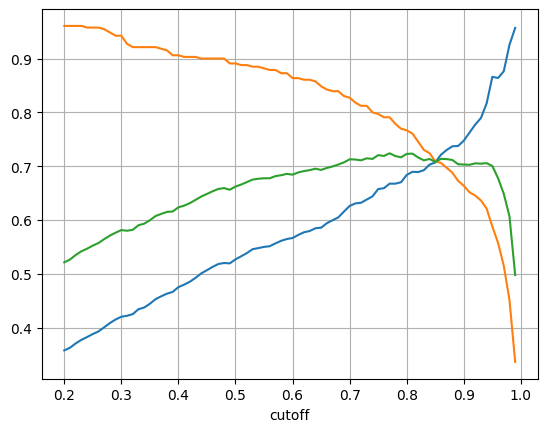

In [9]:
probas = xr.DataArray(torch.nn.Sigmoid()(y_scores), dims=['time','timestep'])
cutoff = xr.DataArray(np.arange(.2,1,.01), dims=['cutoff'], coords=dict(cutoff=np.arange(.2,1,.01)))
predictions = (probas>cutoff)*1
true_labels = xr.DataArray((y_validation>0.5)*1, dims=['time','timestep'])

TP = ((predictions==true_labels)&(predictions==1)).sum(['time','timestep'])
precision = TP/((predictions==1)).sum(['time','timestep'])
recall = TP/((true_labels==1)).sum(['time','timestep'])
precision.plot()
recall.plot()
f1_score = precision*recall/(precision+recall)*2
f1_score.plot()
plt.grid()

In [ ]:

TP = ((true_labels==1)*(predictions==1)).sum(axis=0)
precision = TP/((predictions==1)).sum(axis=0)
recall = TP/((true_labels==1)).sum(axis=0)

precision

tensor([0.3105, 0.2733, 0.2032, 0.1701])

In [5]:
from lightning import Callback
import torch 
import pandas as pd
import wandb
import numpy as np
from scipy.stats import pearsonr
import xarray as xr
from lightning.pytorch.callbacks import ModelCheckpoint
class LogF1Validation(Callback):
    def __init__(self, label_of_target=2):
        self.label_of_target = label_of_target
    def on_validation_start(self, trainer, model):
        self.predictions_validation = []
        self.targets_validation = []
    def on_validation_end(self, trainer, model):
        y_validation = torch.stack(model.targets_validation)#.cpu().numpy()
        y_scores = torch.stack(model.predictions_validation).view(-1, 4, 3).cpu()
        preds = torch.argmax(y_scores, dim=2) 
        targets = y_validation.cpu().numpy()
        model.predictions_validation = preds 
        model.targets_validation = targets
        TP = ((model.predictions_validation==model.targets_validation) &(model.targets_validation==self.label_of_target)).sum(axis=0)
        recall = TP / (model.targets_validation==self.label_of_target).sum(axis=0)
        precision = TP / (model.predictions_validation==self.label_of_target).sum(axis=0)
        f1 = 2*(precision*recall)/(precision+recall)
        model.f1_per_day = f1

        TP = ((model.predictions_validation==model.targets_validation) &(model.targets_validation==self.label_of_target)).sum()
        recall = TP / (model.targets_validation==self.label_of_target).sum()
        precision = TP / (model.predictions_validation==self.label_of_target).sum()
        f1 = 2*(precision*recall)/(precision+recall)

        model.precision_validation = precision
        model.recall_validation = recall
        model.f1_validation = f1
        wandb.log({"val/precision_epoch": model.precision_validation,
                   "val/recall_epoch": model.recall_validation,
                   "val/f1_epoch": model.f1_validation})
        

    def on_test_start(self, trainer, model):
        self.predictions_test = []
        self.targets_test = []

    def on_test_end(self, trainer, model):
        y_test = torch.stack(model.targets_test)#.cpu().numpy()
        y_scores = torch.stack(model.predictions_test).view(-1, 4, 3).cpu()
        preds = torch.argmax(y_scores, dim=2) 
        targets = y_test.cpu().numpy()
        model.predictions_test = preds 
        model.targets_test = targets
        TP = ((model.predictions_test==model.targets_test) &(model.targets_test==self.label_of_target)).sum(axis=0)
        recall = TP / (model.targets_test==self.label_of_target).sum(axis=0)
        precision = TP / (model.predictions_test==self.label_of_target).sum(axis=0)
        f1 = 2*(precision*recall)/(precision+recall)
        model.f1_per_day_test = f1

        # xr_targets=xr.DataArray(y_test.cpu().numpy(), dims=['time','timestep'], coords=dict(time=trainer.ds_test.time[:y_test.shape[0]], timestep=np.arange(y_scores.shape[1])))
        # xr_preds=xr.DataArray(preds.cpu().numpy(), dims=['time','timestep'], coords=dict(time=trainer.ds_test.time[:y_test.shape[0]], timestep=np.arange(y_scores.shape[1])))
        trainer.targets_test  = targets
        trainer.predictions_test = preds
        table_out = wandb.Table(columns=["Day", "F1","Precision","Recall"],
                            data = np.array([[k for k in range(len(f1))], f1, precision, recall]).T)
        wandb.log({"test/results_per_day_plot":table_out})
        

In [24]:
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([10]))

In [25]:
loss_fn(targets, preds)

tensor(0.8841, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [17]:
ds_rain = xr.open_dataarray(config['file_name_data_out'])
ds_dynamics = xr.open_dataset(config['file_name_data_in'])

In [90]:

def preprocess_rain(ds_rain, type_predictions, quantile_extreme, quantile_extreme_based_on_rainy_days):
    match type_predictions:
        case 'regression':
            return ds_rain
        case 'quantiles':
            return (ds_rain.rank('time', pct=True)//.1).astype(int)
        case 'boolean':
            if quantile_extreme_based_on_rainy_days:
                quantile_extreme_rain =  ds_rain.where(ds_rain>1).quantile(quantile_extreme, 'time')
            else:
                quantile_extreme_rain =  ds_rain.quantile(quantile_extreme, 'time')
            return ((ds_rain > quantile_extreme_rain)*1).astype(int)
        case 'boolean_smooth':
            if quantile_extreme_based_on_rainy_days:
                quantile_extreme_rain =  ds_rain.where(ds_rain>1).quantile(quantile_extreme, 'time').values
            else:
                quantile_extreme_rain =  ds_rain.quantile(quantile_extreme, 'time').values
            return sigmoid_soft_label(ds_rain, threshold=quantile_extreme_rain, width=quantile_extreme_rain/10).astype(float)
        case 'three_classes':
            if quantile_extreme_based_on_rainy_days:
                quantile_extreme_rain =  ds_rain.where(ds_rain>1).quantile(quantile_extreme, 'time')
            else:
                quantile_extreme_rain =  ds_rain.quantile(quantile_extreme, 'time')
            no_rain = xr.ones_like(ds_rain).where(ds_rain>1,0)
            return no_rain.where(ds_rain<quantile_extreme_rain,2).astype(int)
        case _:
            raise ValueError("type_predictions must be 'boolean', 'three_classes', 'quantiles' or 'regression'")


In [13]:
config

{'batch_size': 512, 'learning_rate': 0.0001, 'lr_scheduler': 'step', 'num_epochs': 100, 'loss_function': 'BCEwithlogits', 'file_name_data_out': '/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc', 'type_prediction': 'boolean_smooth', 'quantile_extreme': 0.9, 'quantile_extreme_based_on_rainy_days': True, 'num_timesteps_predicted': 4, 'season': 'all', 'augment_training_with_noise': False, 'num_noisy_samples': 0, 'augment_noise_amplitude': 0.5, 'file_name_data_in': '/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr', 'inputs': 'u850', 'spatial_extent': [-128, 53, 0, 90], 'MLP_hidden_layers_neuron_number': [512, 512], 'use_skip_connections': False, 'CNN_layer_module': 'ConvLayerStride1MaxPool_dropout', 'num_conv_layer': 6, 'size_conv_kernel': 3, 'conv1_kernel_number': 32, 'factor_increase_kernels_per_conv_layer': 2, 'attribute_predictions': 'TP', 'prediction_per_timestep': 1, 'num_classes': 4, 'input_variables': 

In [ ]:
ds_rain = xr.open_dataarray(config['file_name_data_out'])

quantile_extreme_based_on_rainy_days=True
quantile_extreme = .9

if quantile_extreme_based_on_rainy_days:
    quantile_extreme_rain =  ds_rain.where(ds_rain>1).quantile(quantile_extreme, 'time')
else:
    quantile_extreme_rain =  ds_rain.quantile(quantile_extreme, 'time')
no_extreme = xr.ones_like(ds_rain).where(ds_rain>quantile_extreme_rain*0.9,0)
three_classes = no_extreme.where(ds_rain<quantile_extreme_rain*1.1,2).astype(int)
# return three_classes

In [22]:
three_classes.to_series().value_counts()

tp
0    28638
2     1582
1     1008
Name: count, dtype: int64

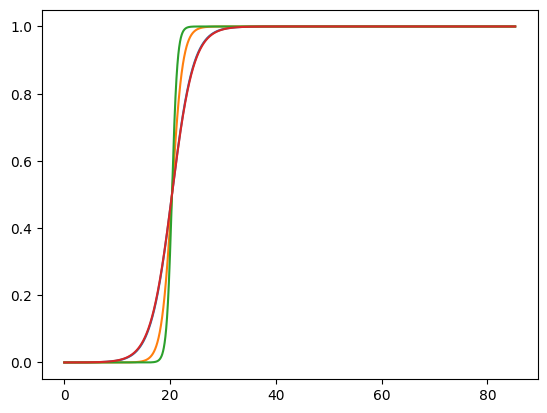

In [89]:
rain = ds_rain.to_series().sort_values()
plt.plot(rain, sigmoid_soft_label(rain, quantile_extreme_rain.values, width=2))
plt.plot(rain, sigmoid_soft_label(rain, quantile_extreme_rain.values, width=1))
plt.plot(rain, sigmoid_soft_label(rain, quantile_extreme_rain.values, width=0.5))
plt.plot(rain, sigmoid_soft_label(rain, quantile_extreme_rain.values, width=quantile_extreme_rain.values/10))


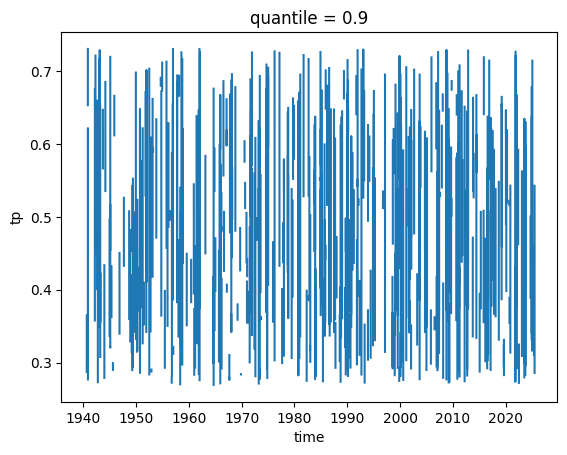

In [56]:
quantile_extreme_based_on_rainy_days = True
quantile_extreme = .9

if quantile_extreme_based_on_rainy_days:
    quantile_extreme_rain =  ds_rain.where(ds_rain>1).quantile(quantile_extreme, 'time')
else:
    quantile_extreme_rain =  ds_rain.quantile(quantile_extreme, 'time')
ds_out =  ((ds_rain > quantile_extreme_rain)*1).astype(int)
# make a buffer area of +- 10%

buffer_rain = (ds_rain-quantile_extreme_rain*0.9)/(quantile_extreme_rain*.2)
buffer_rain=buffer_rain.where(np.abs(buffer_rain)<1)
buffer_rain = 1/(1+np.exp(-buffer_rain))
ds_rain.where((ds_rain<quantile_extreme_rain*1.1) & (ds_rain>quantile_extreme_rain*0.9), drop=True)
buffer_rain.plot()

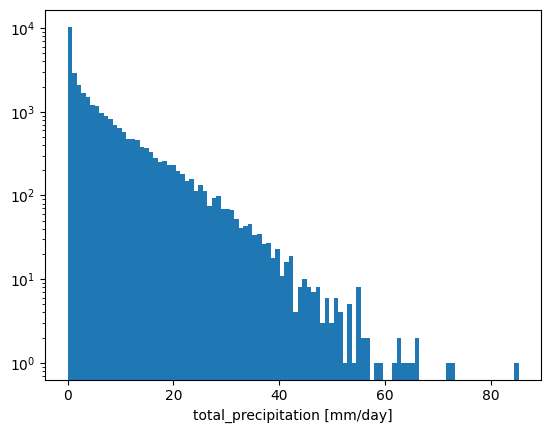

In [22]:
ds_rain.plot.hist(bins=100)
plt.yscale('log')